In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from causalimpact import CausalImpact
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Users\91906\OneDrive\Desktop\causal_inference_project\venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Libraries loaded ✅


In [2]:
df = pd.read_csv('../data/advertising.csv', index_col=0)

df['week'] = pd.date_range(start='2021-01-01', periods=len(df), freq='W')
df = df.set_index('week')

ci_data = df[['Sales', 'TV', 'Radio', 'Newspaper']]

print("Data prepared ✅")
print("Shape:", ci_data.shape)
ci_data.head()

Data prepared ✅
Shape: (200, 4)


,Sales,TV,Radio,Newspaper
week,,,,
2021-01-03,22.1,230.1,37.8,69.2
2021-01-10,10.4,44.5,39.3,45.1
2021-01-17,9.3,17.2,45.9,69.3
2021-01-24,18.5,151.5,41.3,58.5
2021-01-31,12.9,180.8,10.8,58.4


In [3]:
# Campaign started at row 140
# Before campaign: rows 1 to 139
# After campaign: rows 140 to 200

pre_period  = ['2021-01-03', '2023-08-27']
post_period = ['2023-09-03', '2024-11-10']

print("Pre period (before campaign):", pre_period)
print("Post period (after campaign):", post_period)

Pre period (before campaign): ['2021-01-03', '2023-08-27']
Post period (after campaign): ['2023-09-03', '2024-11-10']


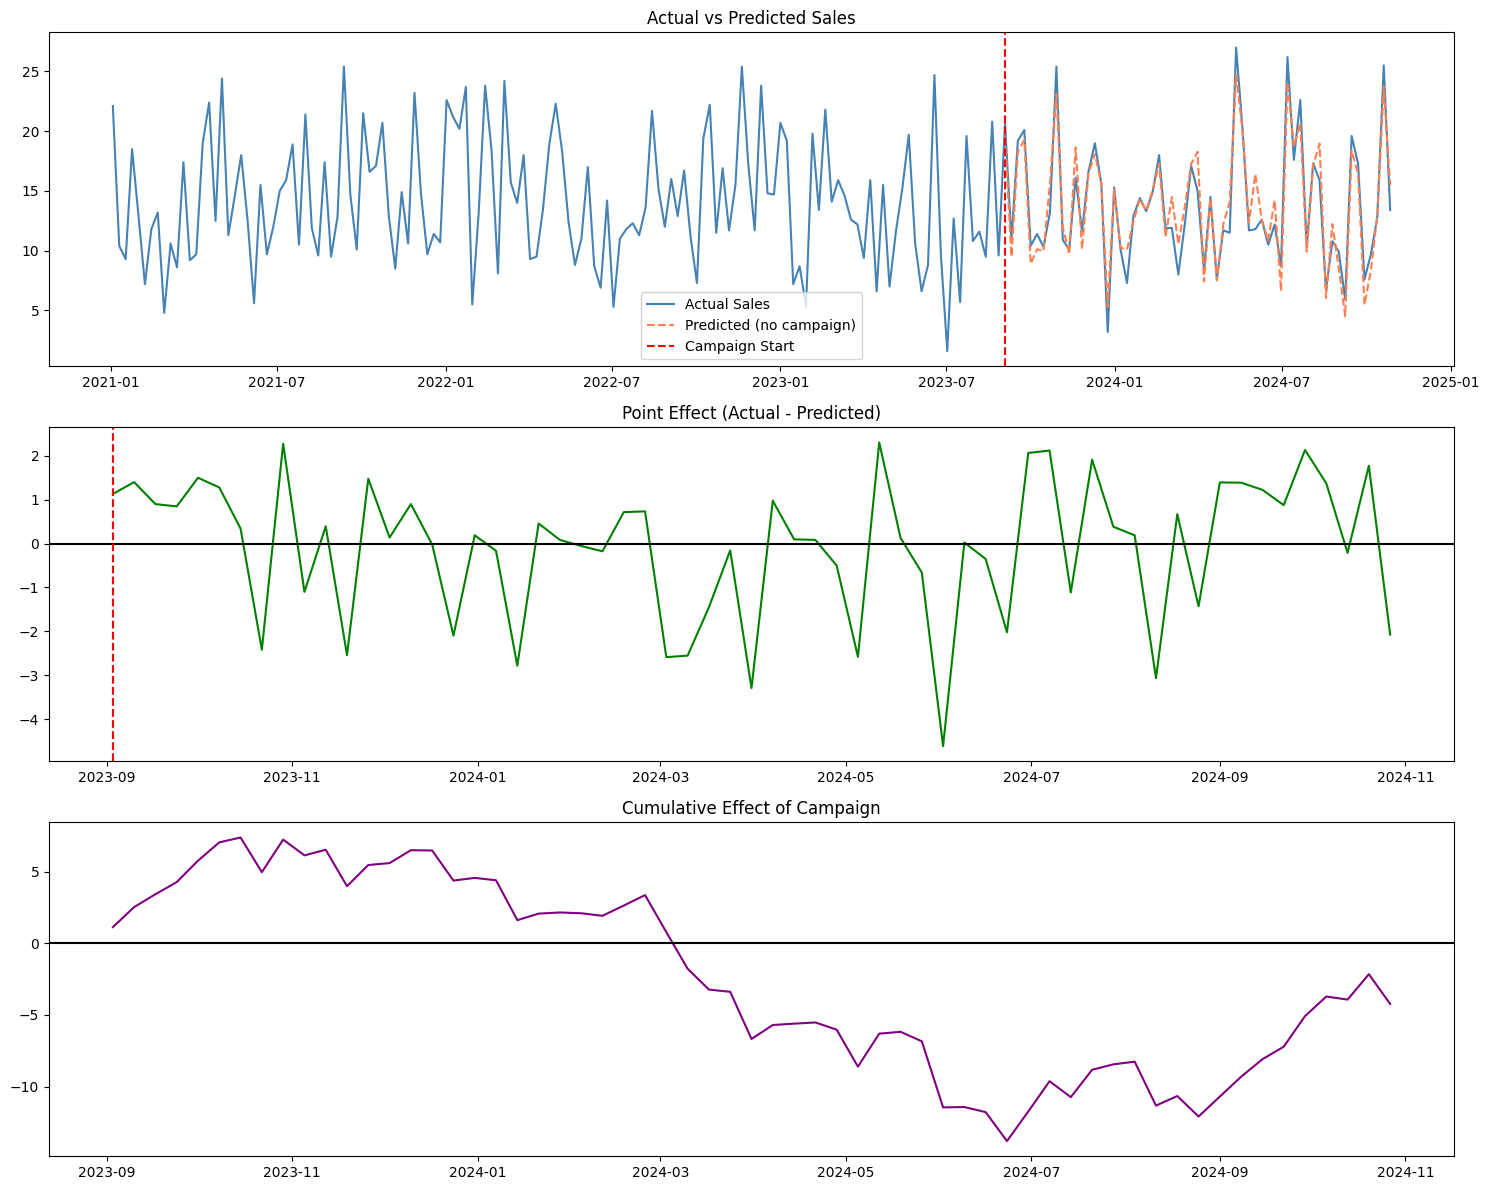

Causal Impact chart saved ✅


In [10]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Split data into pre and post campaign
pre_data  = ci_data[ci_data.index < '2023-09-03']
post_data = ci_data[ci_data.index >= '2023-09-03']

# Build prediction model on pre-campaign data
X_pre  = sm.add_constant(pre_data[['TV', 'Radio', 'Newspaper']])
X_post = sm.add_constant(post_data[['TV', 'Radio', 'Newspaper']])

model = sm.OLS(pre_data['Sales'], X_pre).fit()

# Predict what sales WOULD have been without campaign
predicted_post = model.predict(X_post)

# Plot actual vs predicted
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Chart 1 - Actual vs Predicted
axes[0].plot(ci_data.index, ci_data['Sales'],
             label='Actual Sales', color='steelblue')
axes[0].plot(post_data.index, predicted_post,
             label='Predicted (no campaign)', color='coral',
             linestyle='--')
axes[0].axvline(x=pd.Timestamp('2023-09-03'),
                color='red', linestyle='--', label='Campaign Start')
axes[0].set_title('Actual vs Predicted Sales')
axes[0].legend()

# Chart 2 - Point Effect
point_effect = post_data['Sales'].values - predicted_post.values
axes[1].plot(post_data.index, point_effect, color='green')
axes[1].axhline(y=0, color='black', linestyle='-')
axes[1].axvline(x=pd.Timestamp('2023-09-03'),
                color='red', linestyle='--')
axes[1].set_title('Point Effect (Actual - Predicted)')

# Chart 3 - Cumulative Effect
cum_effect = point_effect.cumsum()
axes[2].plot(post_data.index, cum_effect, color='purple')
axes[2].axhline(y=0, color='black', linestyle='-')
axes[2].set_title('Cumulative Effect of Campaign')

plt.tight_layout()
plt.savefig('../reports/causal_impact_result.png', bbox_inches='tight')
plt.show()
print("Causal Impact chart saved ✅")

In [11]:
avg_actual    = post_data['Sales'].mean()
avg_predicted = predicted_post.mean()
avg_effect    = point_effect.mean()
total_effect  = point_effect.sum()

print("=== CAMPAIGN IMPACT SUMMARY ===")
print()
print(f"Average actual sales per week:       {avg_actual:.2f}")
print(f"Average predicted (no campaign):     {avg_predicted:.2f}")
print(f"Average campaign effect per week:    {avg_effect:.2f}")
print(f"Total cumulative effect:             {total_effect:.2f}")
print(f"Percentage lift:                     {(avg_effect/avg_predicted*100):.1f}%")

=== CAMPAIGN IMPACT SUMMARY ===

Average actual sales per week:       13.84
Average predicted (no campaign):     13.91
Average campaign effect per week:    -0.07
Total cumulative effect:             -4.23
Percentage lift:                     -0.5%
